# Coffee Search Trends Analysis: Chicago vs Florida

This notebook analyzes Google Trends data for coffee searches in Chicago and Florida across multiple time periods:
- Long-term data since 2004
- 5-year data (2020-2025)
- 12-month data (recent year)

We'll compare the trends between these two locations and create forecasts for the next 12 months.

## Analysis Overview:
1. **Data Loading & Preprocessing**: Load and clean CSV files from different time periods
2. **Exploratory Data Analysis**: Examine trends, seasonality, and patterns
3. **Comparative Visualization**: Compare Chicago vs Florida search trends
4. **Time Series Forecasting**: Build models to predict next 12 months
5. **Results Comparison**: Analyze forecast differences between locations

## 1. Import Required Libraries

In [1]:
# Data manipulation and analysis
import pandas as pd
import numpy as np
from datetime import datetime, timedelta
import warnings
warnings.filterwarnings('ignore')

# Data visualization
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import seaborn as sns
plt.style.use('default')
sns.set_palette("husl")

# Time series analysis and forecasting
from statsmodels.tsa.seasonal import seasonal_decompose
from statsmodels.tsa.arima.model import ARIMA
from statsmodels.tsa.statespace.sarimax import SARIMAX
from statsmodels.tsa.stattools import adfuller
from sklearn.metrics import mean_absolute_error, mean_squared_error

# Prophet for forecasting (if available)
try:
    from prophet import Prophet
    PROPHET_AVAILABLE = True
    print("Prophet library is available for forecasting")
except ImportError:
    PROPHET_AVAILABLE = False
    print("Prophet library not available, will use ARIMA models instead")

print("All required libraries imported successfully!")
print(f"Pandas version: {pd.__version__}")
print(f"NumPy version: {np.__version__}")
print(f"Matplotlib version: {plt.matplotlib.__version__}")
print(f"Seaborn version: {sns.__version__}")

Prophet library not available, will use ARIMA models instead
All required libraries imported successfully!
Pandas version: 2.2.3
NumPy version: 1.26.4
Matplotlib version: 3.9.3
Seaborn version: 0.13.2


## 2. Load and Explore CSV Data

We have several CSV files with different time periods and granularities:
- **Long-term (2004-2025)**: Monthly data since 2004
- **5-year period**: Weekly data from 2020-2025  
- **12-month period**: Recent weekly data

Let's load and examine each dataset:

In [2]:
# Define file paths
data_path = r"c:\Users\user\OneDrive\Documents\D_I_G\ML\My Data & Projects\coffe"

# Load all CSV files
csv_files = {
    'us_hourly': f'{data_path}/multiTimeline.csv',           # Recent hourly US data
    'us_5year': f'{data_path}/multiTimeline (1).csv',       # 5-year weekly US data  
    'us_longterm': f'{data_path}/multiTimeline (2).csv',    # Long-term monthly US data
    'florida_longterm': f'{data_path}/multiTimeline (3).csv',    # Long-term monthly Florida data
    'florida_5year': f'{data_path}/multiTimeline (4).csv',      # 5-year weekly Florida data  
    'florida_12month': f'{data_path}/multiTimeline (5).csv',    # 12-month weekly Florida data
    'illinois_12month': f'{data_path}/multiTimeline (6).csv',   # 12-month weekly Illinois data
    'illinois_5year': f'{data_path}/multiTimeline (7).csv',     # 5-year weekly Illinois data
    'chicago_longterm': f'{data_path}/multiTimeline (8).csv',   # Long-term monthly Chicago data
    'tampa_longterm': f'{data_path}/multiTimeline (9).csv'     # Long-term monthly Tampa data
}

# Function to load and examine CSV structure
def load_and_examine_csv(filepath, name):
    """Load CSV and return basic info"""
    try:
        # Read first few lines to understand structure
        with open(filepath, 'r') as f:
            lines = f.readlines()[:5]
        
        print(f"\n=== {name.upper()} ===")
        print(f"File: {filepath}")
        print("First few lines:")
        for i, line in enumerate(lines):
            print(f"Line {i+1}: {line.strip()}")
            
        # Load the actual data (skip the category line)
        df = pd.read_csv(filepath, skiprows=1)
        print(f"\nData shape: {df.shape}")
        print(f"Columns: {list(df.columns)}")
        print(f"Date range: {df.iloc[0, 0]} to {df.iloc[-1, 0]}")
        print(f"Sample values: {df.iloc[:3, 1].tolist()}")
        
        return df
    except Exception as e:
        print(f"Error loading {name}: {e}")
        return None

# Load all datasets
datasets = {}
for name, filepath in csv_files.items():
    datasets[name] = load_and_examine_csv(filepath, name)


=== US_HOURLY ===
File: c:\Users\user\OneDrive\Documents\D_I_G\ML\My Data & Projects\coffe/multiTimeline.csv
First few lines:
Line 1: Category: All categories
Line 2: 
Line 3: Time,coffee: (United States)
Line 4: 2025-08-04T22:20:00-05:00,47
Line 5: 2025-08-04T22:28:00-05:00,49

Data shape: (180, 2)
Columns: ['Time', 'coffee: (United States)']
Date range: 2025-08-04T22:20:00-05:00 to 2025-08-05T22:12:00-05:00
Sample values: [47, 49, 46]

=== US_5YEAR ===
File: c:\Users\user\OneDrive\Documents\D_I_G\ML\My Data & Projects\coffe/multiTimeline (1).csv
First few lines:
Line 1: Category: All categories
Line 2: 
Line 3: Week,coffee: (United States)
Line 4: 2020-08-02,63
Line 5: 2020-08-09,64

Data shape: (262, 2)
Columns: ['Week', 'coffee: (United States)']
Date range: 2020-08-02 to 2025-08-03
Sample values: [63, 64, 62]

=== US_LONGTERM ===
File: c:\Users\user\OneDrive\Documents\D_I_G\ML\My Data & Projects\coffe/multiTimeline (2).csv
First few lines:
Line 1: Category: All categories
Line 2:

## 3. Data Preprocessing and Cleaning

Now let's clean and standardize the data from different sources:

In [3]:
def clean_and_standardize_data(df, location_name, time_frequency):
    """
    Clean and standardize the dataframe
    """
    if df is None:
        return None
    
    # Make a copy to avoid modifying original
    df_clean = df.copy()
    
    # Standardize column names
    columns = df_clean.columns.tolist()
    if len(columns) >= 2:
        df_clean.columns = ['date', 'search_volume']
    
    # Convert date column to datetime
    try:
        df_clean['date'] = pd.to_datetime(df_clean['date'])
    except:
        print(f"Error converting dates for {location_name}")
        return None
    
    # Ensure search_volume is numeric
    df_clean['search_volume'] = pd.to_numeric(df_clean['search_volume'], errors='coerce')
    
    # Add metadata columns
    df_clean['location'] = location_name
    df_clean['frequency'] = time_frequency
    
    # Remove any rows with missing search volume
    df_clean = df_clean.dropna(subset=['search_volume'])
    
    # Sort by date
    df_clean = df_clean.sort_values('date').reset_index(drop=True)
    
    return df_clean

# Clean each dataset
print("Cleaning datasets...")

cleaned_data = {}

# Chicago data
cleaned_data['chicago_longterm'] = clean_and_standardize_data(
    datasets['chicago_longterm'], 'Chicago', 'monthly'
)
cleaned_data['chicago_5year'] = clean_and_standardize_data(
    datasets['illinois_5year'], 'Chicago', 'weekly'  
)
cleaned_data['chicago_12month'] = clean_and_standardize_data(
    datasets['illinois_12month'], 'Chicago', 'weekly'
)

# Florida data  
cleaned_data['florida_longterm'] = clean_and_standardize_data(
    datasets['florida_longterm'], 'Florida', 'monthly'
)
cleaned_data['florida_5year'] = clean_and_standardize_data(
    datasets['florida_5year'], 'Florida', 'weekly'
)
cleaned_data['florida_12month'] = clean_and_standardize_data(
    datasets['florida_12month'], 'Florida', 'weekly'
)

# Display cleaned data info
for name, df in cleaned_data.items():
    if df is not None:
        print(f"\n{name.upper()}:")
        print(f"  Shape: {df.shape}")
        print(f"  Date range: {df['date'].min()} to {df['date'].max()}")
        print(f"  Search volume range: {df['search_volume'].min()} to {df['search_volume'].max()}")
        print(f"  Missing values: {df['search_volume'].isna().sum()}")
    else:
        print(f"\n{name.upper()}: Failed to load")

Cleaning datasets...

CHICAGO_LONGTERM:
  Shape: (260, 4)
  Date range: 2004-01-01 00:00:00 to 2025-08-01 00:00:00
  Search volume range: 24 to 100
  Missing values: 0

CHICAGO_5YEAR:
  Shape: (262, 4)
  Date range: 2020-08-02 00:00:00 to 2025-08-03 00:00:00
  Search volume range: 51 to 100
  Missing values: 0

CHICAGO_12MONTH:
  Shape: (53, 4)
  Date range: 2024-08-04 00:00:00 to 2025-08-03 00:00:00
  Search volume range: 74 to 100
  Missing values: 0

FLORIDA_LONGTERM:
  Shape: (260, 4)
  Date range: 2004-01-01 00:00:00 to 2025-08-01 00:00:00
  Search volume range: 21 to 100
  Missing values: 0

FLORIDA_5YEAR:
  Shape: (262, 4)
  Date range: 2020-08-02 00:00:00 to 2025-08-03 00:00:00
  Search volume range: 42 to 100
  Missing values: 0

FLORIDA_12MONTH:
  Shape: (53, 4)
  Date range: 2024-08-04 00:00:00 to 2025-08-03 00:00:00
  Search volume range: 60 to 100
  Missing values: 0


## 4. Combine Different Time Periods

We'll create comprehensive datasets for each location by combining different time periods while avoiding duplicates:

In [4]:
def combine_time_periods(longterm_df, weekly_df, location_name):
    """
    Combine long-term monthly data with weekly data, preferring weekly when available
    """
    if longterm_df is None:
        return weekly_df
    if weekly_df is None:
        return longterm_df
    
    combined_data = []
    
    # Use long-term data for early periods (before weekly data starts)
    weekly_start = weekly_df['date'].min()
    early_data = longterm_df[longterm_df['date'] < weekly_start].copy()
    if not early_data.empty:
        combined_data.append(early_data)
    
    # Use weekly data for the overlapping and recent period
    combined_data.append(weekly_df)
    
    # Combine all data
    if combined_data:
        result = pd.concat(combined_data, ignore_index=True)
        result = result.sort_values('date').reset_index(drop=True)
        
        # Remove any duplicate dates (prefer weekly over monthly)
        result = result.drop_duplicates(subset=['date'], keep='last')
        
        return result
    else:
        return longterm_df

# Combine datasets for each location
print("Combining time periods...")

# For Chicago - combine long-term monthly with 5-year weekly data
chicago_combined = combine_time_periods(
    cleaned_data['chicago_longterm'], 
    cleaned_data['chicago_5year'], 
    'Chicago'
)

# For Florida - combine long-term monthly with 5-year weekly data  
florida_combined = combine_time_periods(
    cleaned_data['florida_longterm'],
    cleaned_data['florida_5year'], 
    'Florida'
)

# Display combined data summary
print(f"\nCHICAGO COMBINED:")
if chicago_combined is not None:
    print(f"  Shape: {chicago_combined.shape}")
    print(f"  Date range: {chicago_combined['date'].min()} to {chicago_combined['date'].max()}")
    print(f"  Data points: {len(chicago_combined)}")
    
    # Show frequency distribution
    chicago_combined['year'] = chicago_combined['date'].dt.year
    freq_dist = chicago_combined.groupby('year').size()
    print(f"  Data points per year (recent): {freq_dist.tail()}")
else:
    print("  Failed to combine")

print(f"\nFLORIDA COMBINED:")
if florida_combined is not None:
    print(f"  Shape: {florida_combined.shape}")
    print(f"  Date range: {florida_combined['date'].min()} to {florida_combined['date'].max()}")
    print(f"  Data points: {len(florida_combined)}")
    
    # Show frequency distribution  
    florida_combined['year'] = florida_combined['date'].dt.year
    freq_dist = florida_combined.groupby('year').size()
    print(f"  Data points per year (recent): {freq_dist.tail()}")
else:
    print("  Failed to combine")

# Create a master comparison dataset
if chicago_combined is not None and florida_combined is not None:
    # Ensure both have the same date column type
    chicago_combined['location'] = 'Chicago'
    florida_combined['location'] = 'Florida'
    
    comparison_data = pd.concat([chicago_combined, florida_combined], ignore_index=True)
    comparison_data = comparison_data.sort_values(['date', 'location']).reset_index(drop=True)
    
    print(f"\nCOMPARISON DATASET:")
    print(f"  Total shape: {comparison_data.shape}")
    print(f"  Date range: {comparison_data['date'].min()} to {comparison_data['date'].max()}")
    print(f"  Locations: {comparison_data['location'].unique()}")
else:
    comparison_data = None
    print("\nFailed to create comparison dataset")

Combining time periods...

CHICAGO COMBINED:
  Shape: (462, 4)
  Date range: 2004-01-01 00:00:00 to 2025-08-03 00:00:00
  Data points: 462
  Data points per year (recent): year
2021    52
2022    52
2023    53
2024    52
2025    31
dtype: int64

FLORIDA COMBINED:
  Shape: (462, 4)
  Date range: 2004-01-01 00:00:00 to 2025-08-03 00:00:00
  Data points: 462
  Data points per year (recent): year
2021    52
2022    52
2023    53
2024    52
2025    31
dtype: int64

COMPARISON DATASET:
  Total shape: (924, 5)
  Date range: 2004-01-01 00:00:00 to 2025-08-03 00:00:00
  Locations: ['Chicago' 'Florida']


## 5. Exploratory Data Analysis

Let's analyze the trends, seasonality, and statistical properties of the coffee search data:

In [5]:
# Summary statistics for each location
def analyze_location_data(df, location_name):
    """Generate comprehensive statistics for location data"""
    
    print(f"\n=== {location_name.upper()} ANALYSIS ===")
    print(f"Data points: {len(df)}")
    print(f"Date range: {df['date'].min().strftime('%Y-%m-%d')} to {df['date'].max().strftime('%Y-%m-%d')}")
    print(f"Duration: {(df['date'].max() - df['date'].min()).days} days")
    
    # Basic statistics
    search_stats = df['search_volume'].describe()
    print(f"\nSearch Volume Statistics:")
    for stat, value in search_stats.items():
        print(f"  {stat.capitalize()}: {value:.2f}")
    
    # Year-over-year analysis (for data with multiple years)
    df_with_year = df.copy()
    df_with_year['year'] = df_with_year['date'].dt.year
    df_with_year['month'] = df_with_year['date'].dt.month
    
    yearly_stats = df_with_year.groupby('year')['search_volume'].agg(['mean', 'std', 'min', 'max']).round(2)
    print(f"\nYearly Trends:")
    print(yearly_stats.tail())
    
    # Monthly seasonality (if enough data)
    if len(df_with_year['year'].unique()) > 1:
        monthly_avg = df_with_year.groupby('month')['search_volume'].mean().round(2)
        print(f"\nMonthly Seasonality (Average by Month):")
        month_names = ['Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun', 
                      'Jul', 'Aug', 'Sep', 'Oct', 'Nov', 'Dec']
        for month, avg in monthly_avg.items():
            print(f"  {month_names[month-1]}: {avg}")
    
    return df_with_year

# Analyze each location
if chicago_combined is not None:
    chicago_analysis = analyze_location_data(chicago_combined, 'Chicago')

if florida_combined is not None:
    florida_analysis = analyze_location_data(florida_combined, 'Florida')

# Comparative analysis
if chicago_combined is not None and florida_combined is not None:
    print(f"\n=== COMPARATIVE ANALYSIS ===")
    
    chicago_mean = chicago_combined['search_volume'].mean()
    florida_mean = florida_combined['search_volume'].mean()
    
    print(f"Average Search Volume:")
    print(f"  Chicago: {chicago_mean:.2f}")
    print(f"  Florida: {florida_mean:.2f}")
    print(f"  Difference: {abs(chicago_mean - florida_mean):.2f}")
    print(f"  Higher: {'Chicago' if chicago_mean > florida_mean else 'Florida'}")
    
    # Volatility comparison
    chicago_std = chicago_combined['search_volume'].std()
    florida_std = florida_combined['search_volume'].std()
    
    print(f"\nVolatility (Standard Deviation):")
    print(f"  Chicago: {chicago_std:.2f}")
    print(f"  Florida: {florida_std:.2f}")
    print(f"  More volatile: {'Chicago' if chicago_std > florida_std else 'Florida'}")
    
    # Growth trend analysis (comparing first vs last year averages)
    chicago_first_year = chicago_combined[chicago_combined['date'].dt.year == chicago_combined['date'].dt.year.min()]['search_volume'].mean()
    chicago_last_year = chicago_combined[chicago_combined['date'].dt.year == chicago_combined['date'].dt.year.max()]['search_volume'].mean()
    chicago_growth = ((chicago_last_year - chicago_first_year) / chicago_first_year) * 100
    
    florida_first_year = florida_combined[florida_combined['date'].dt.year == florida_combined['date'].dt.year.min()]['search_volume'].mean()
    florida_last_year = florida_combined[florida_combined['date'].dt.year == florida_combined['date'].dt.year.max()]['search_volume'].mean()
    florida_growth = ((florida_last_year - florida_first_year) / florida_first_year) * 100
    
    print(f"\nLong-term Growth (First vs Last Year):")
    print(f"  Chicago: {chicago_growth:+.1f}%")
    print(f"  Florida: {florida_growth:+.1f}%")


=== CHICAGO ANALYSIS ===
Data points: 462
Date range: 2004-01-01 to 2025-08-03
Duration: 7885 days

Search Volume Statistics:
  Count: 462.00
  Mean: 59.15
  Std: 19.62
  Min: 24.00
  25%: 41.00
  50%: 64.50
  75%: 75.00
  Max: 100.00

Yearly Trends:
       mean   std  min  max
year                       
2021  66.06  6.20   57   86
2022  71.10  4.30   63   83
2023  75.08  5.04   66   87
2024  78.60  5.10   72   96
2025  86.77  5.82   77  100

Monthly Seasonality (Average by Month):
  Jan: 59.65
  Feb: 56.78
  Mar: 57.77
  Apr: 56.68
  May: 56.36
  Jun: 59.08
  Jul: 60.97
  Aug: 57.45
  Sep: 58.73
  Oct: 58.13
  Nov: 62.08
  Dec: 66.32

=== FLORIDA ANALYSIS ===
Data points: 462
Date range: 2004-01-01 to 2025-08-03
Duration: 7885 days

Search Volume Statistics:
  Count: 462.00
  Mean: 52.45
  Std: 16.87
  Min: 21.00
  25%: 39.00
  50%: 56.00
  75%: 64.00
  Max: 100.00

Yearly Trends:
       mean   std  min  max
year                       
2021  56.67  4.04   52   71
2022  61.40  3.02  

## 6. Time Series Visualization Comparison

Let's create comprehensive visualizations to compare the coffee search trends between Chicago and Florida:

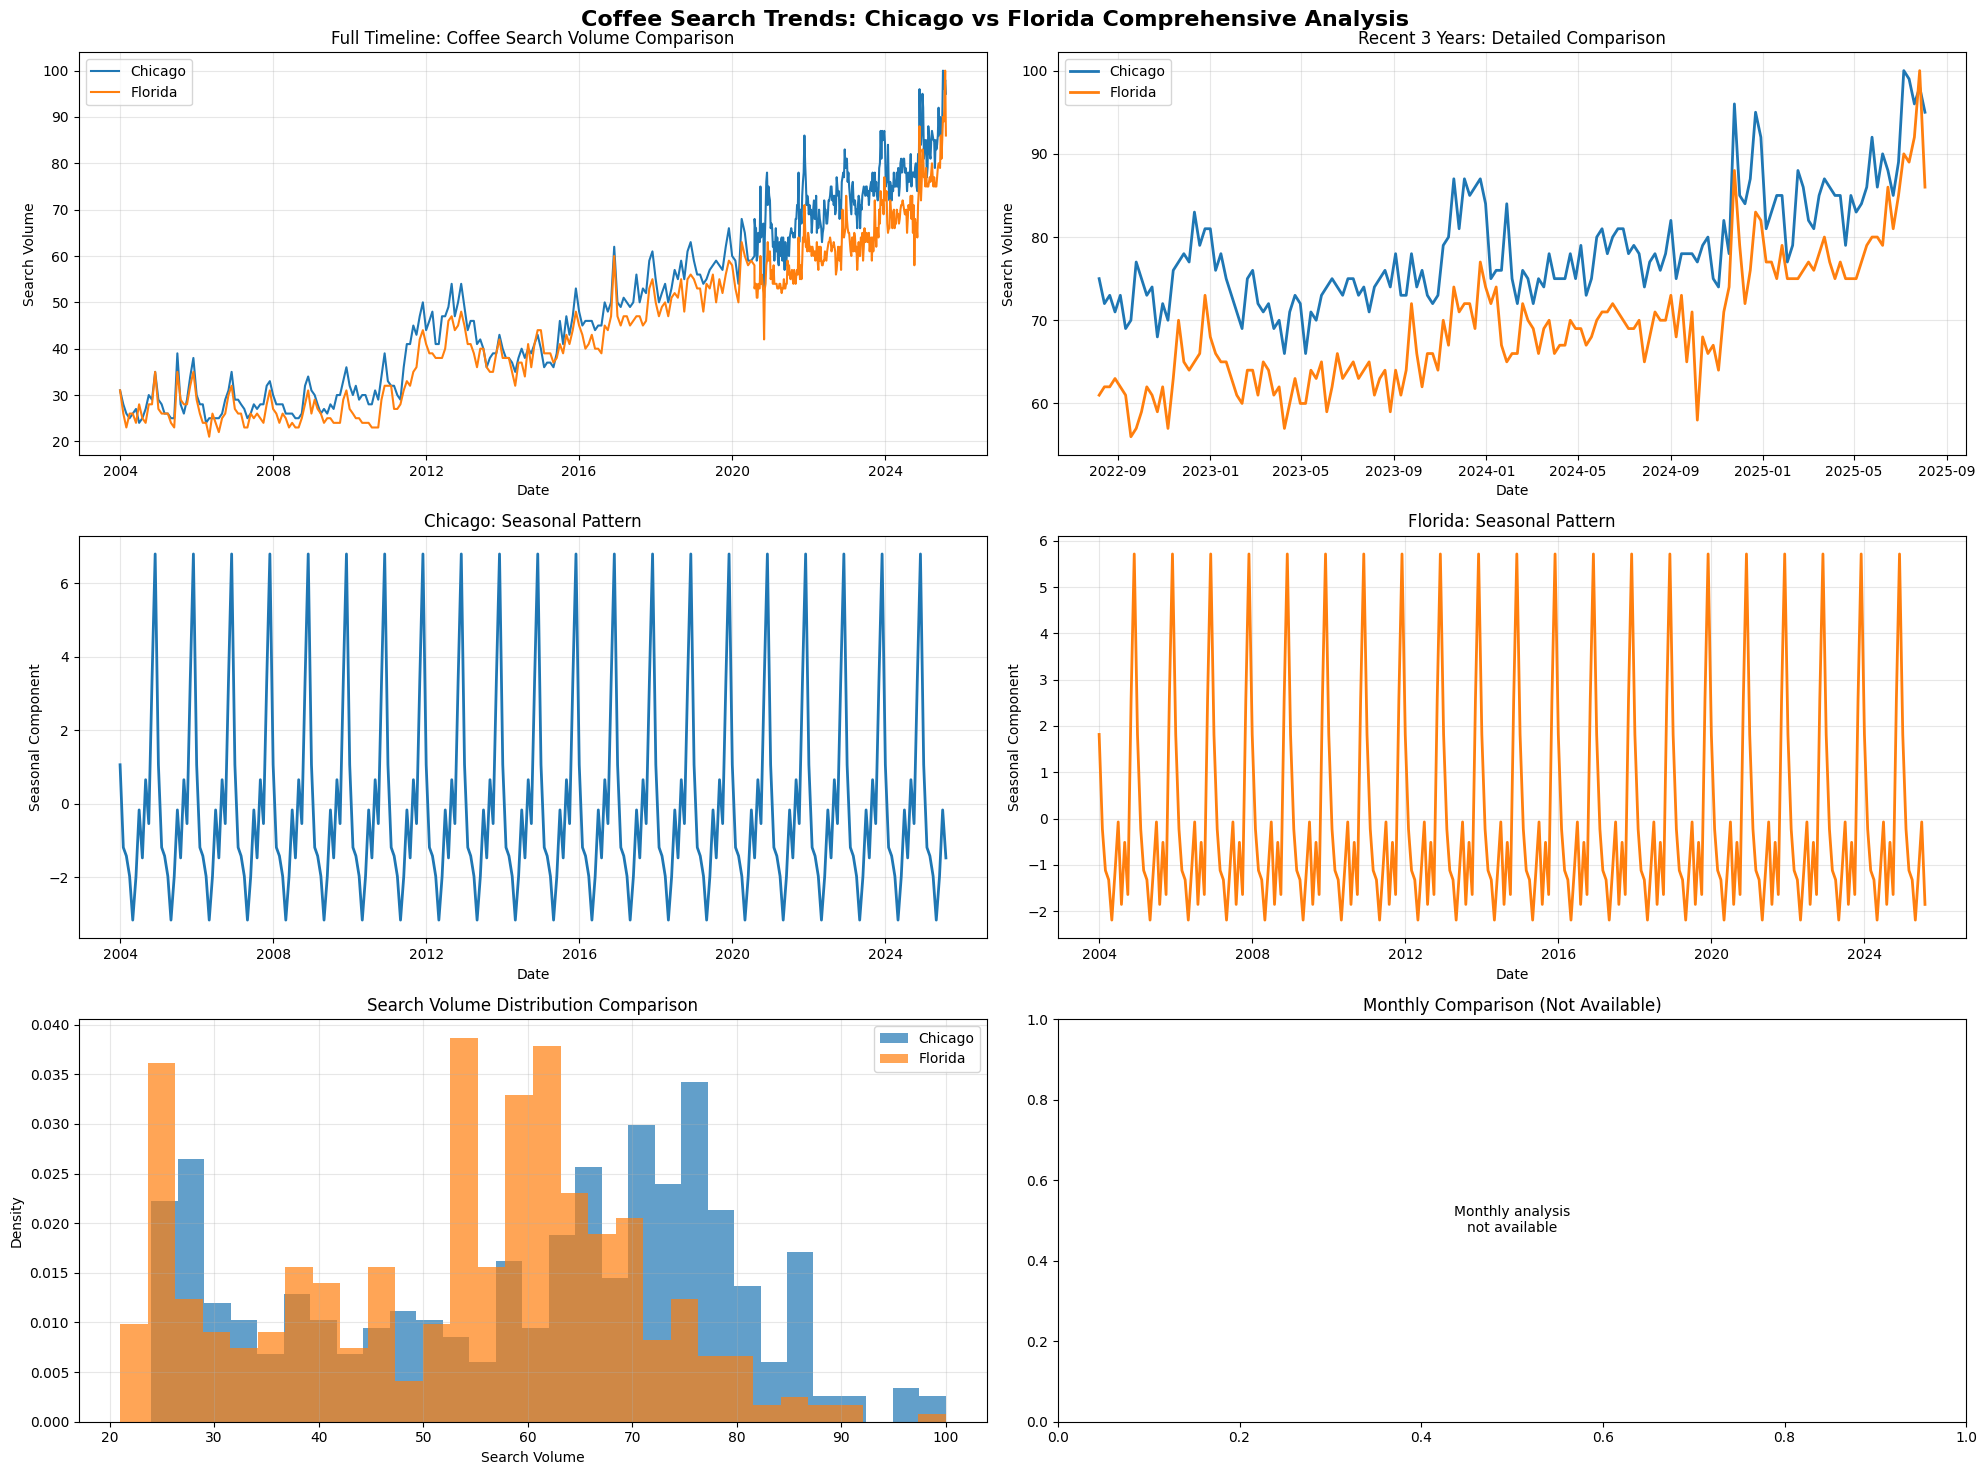


=== CORRELATION ANALYSIS ===
Correlation between Chicago and Florida search volumes: 0.982
Strong positive correlation - similar trends


In [6]:
# Set up visualization parameters
plt.rcParams['figure.figsize'] = (15, 10)
plt.rcParams['font.size'] = 10

# Create comprehensive comparison plots
if chicago_combined is not None and florida_combined is not None:
    
    # 1. Overall Time Series Comparison
    fig, axes = plt.subplots(3, 2, figsize=(20, 15))
    fig.suptitle('Coffee Search Trends: Chicago vs Florida Comprehensive Analysis', fontsize=16, fontweight='bold')
    
    # Plot 1: Full timeline comparison
    ax1 = axes[0, 0]
    ax1.plot(chicago_combined['date'], chicago_combined['search_volume'], 
             label='Chicago', color='#1f77b4', linewidth=1.5)
    ax1.plot(florida_combined['date'], florida_combined['search_volume'], 
             label='Florida', color='#ff7f0e', linewidth=1.5)
    ax1.set_title('Full Timeline: Coffee Search Volume Comparison')
    ax1.set_xlabel('Date')
    ax1.set_ylabel('Search Volume')
    ax1.legend()
    ax1.grid(True, alpha=0.3)
    
    # Plot 2: Recent 3 years comparison
    recent_date = pd.Timestamp.now() - pd.DateOffset(years=3)
    chicago_recent = chicago_combined[chicago_combined['date'] >= recent_date]
    florida_recent = florida_combined[florida_combined['date'] >= recent_date]
    
    ax2 = axes[0, 1]
    if not chicago_recent.empty:
        ax2.plot(chicago_recent['date'], chicago_recent['search_volume'], 
                 label='Chicago', color='#1f77b4', linewidth=2)
    if not florida_recent.empty:
        ax2.plot(florida_recent['date'], florida_recent['search_volume'], 
                 label='Florida', color='#ff7f0e', linewidth=2)
    ax2.set_title('Recent 3 Years: Detailed Comparison')
    ax2.set_xlabel('Date')
    ax2.set_ylabel('Search Volume')
    ax2.legend()
    ax2.grid(True, alpha=0.3)
    
    # Plot 3: Seasonal decomposition - Chicago
    ax3 = axes[1, 0]
    # Create monthly aggregated data for decomposition
    chicago_monthly = chicago_combined.copy()
    chicago_monthly['year_month'] = chicago_monthly['date'].dt.to_period('M')
    chicago_monthly_agg = chicago_monthly.groupby('year_month')['search_volume'].mean().reset_index()
    chicago_monthly_agg['date'] = chicago_monthly_agg['year_month'].dt.to_timestamp()
    
    if len(chicago_monthly_agg) >= 24:  # Need at least 2 years for decomposition
        chicago_ts = chicago_monthly_agg.set_index('date')['search_volume']
        chicago_decomposition = seasonal_decompose(chicago_ts, model='additive', period=12)
        ax3.plot(chicago_decomposition.seasonal.index, chicago_decomposition.seasonal.values, 
                 color='#1f77b4', linewidth=2)
        ax3.set_title('Chicago: Seasonal Pattern')
        ax3.set_xlabel('Date')
        ax3.set_ylabel('Seasonal Component')
        ax3.grid(True, alpha=0.3)
    else:
        ax3.text(0.5, 0.5, 'Insufficient data\nfor decomposition', 
                ha='center', va='center', transform=ax3.transAxes)
        ax3.set_title('Chicago: Seasonal Pattern (Insufficient Data)')
    
    # Plot 4: Seasonal decomposition - Florida
    ax4 = axes[1, 1]
    florida_monthly = florida_combined.copy()
    florida_monthly['year_month'] = florida_monthly['date'].dt.to_period('M')
    florida_monthly_agg = florida_monthly.groupby('year_month')['search_volume'].mean().reset_index()
    florida_monthly_agg['date'] = florida_monthly_agg['year_month'].dt.to_timestamp()
    
    if len(florida_monthly_agg) >= 24:
        florida_ts = florida_monthly_agg.set_index('date')['search_volume']
        florida_decomposition = seasonal_decompose(florida_ts, model='additive', period=12)
        ax4.plot(florida_decomposition.seasonal.index, florida_decomposition.seasonal.values, 
                 color='#ff7f0e', linewidth=2)
        ax4.set_title('Florida: Seasonal Pattern')
        ax4.set_xlabel('Date')
        ax4.set_ylabel('Seasonal Component')
        ax4.grid(True, alpha=0.3)
    else:
        ax4.text(0.5, 0.5, 'Insufficient data\nfor decomposition', 
                ha='center', va='center', transform=ax4.transAxes)
        ax4.set_title('Florida: Seasonal Pattern (Insufficient Data)')
    
    # Plot 5: Distribution comparison
    ax5 = axes[2, 0]
    ax5.hist(chicago_combined['search_volume'], bins=30, alpha=0.7, 
             label='Chicago', color='#1f77b4', density=True)
    ax5.hist(florida_combined['search_volume'], bins=30, alpha=0.7, 
             label='Florida', color='#ff7f0e', density=True)
    ax5.set_title('Search Volume Distribution Comparison')
    ax5.set_xlabel('Search Volume')
    ax5.set_ylabel('Density')
    ax5.legend()
    ax5.grid(True, alpha=0.3)
    
    # Plot 6: Monthly averages comparison (if enough data)
    ax6 = axes[2, 1]
    if 'month' in chicago_combined.columns:
        chicago_monthly_avg = chicago_combined.groupby('month')['search_volume'].mean()
        florida_monthly_avg = florida_combined.groupby('month')['search_volume'].mean()
        
        months = range(1, 13)
        month_names = ['Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun',
                      'Jul', 'Aug', 'Sep', 'Oct', 'Nov', 'Dec']
        
        ax6.plot(months, chicago_monthly_avg, 'o-', label='Chicago', 
                color='#1f77b4', linewidth=2, markersize=6)
        ax6.plot(months, florida_monthly_avg, 'o-', label='Florida', 
                color='#ff7f0e', linewidth=2, markersize=6)
        ax6.set_xticks(months)
        ax6.set_xticklabels(month_names)
        ax6.set_title('Average Monthly Search Volume')
        ax6.set_xlabel('Month')
        ax6.set_ylabel('Average Search Volume')
        ax6.legend()
        ax6.grid(True, alpha=0.3)
    else:
        ax6.text(0.5, 0.5, 'Monthly analysis\nnot available', 
                ha='center', va='center', transform=ax6.transAxes)
        ax6.set_title('Monthly Comparison (Not Available)')
    
    plt.tight_layout()
    plt.show()
    
    # Additional correlation analysis
    print(f"\n=== CORRELATION ANALYSIS ===")
    
    # Align data by date for correlation
    chicago_aligned = chicago_combined.set_index('date')['search_volume']
    florida_aligned = florida_combined.set_index('date')['search_volume']
    
    # Find common dates
    common_dates = chicago_aligned.index.intersection(florida_aligned.index)
    
    if len(common_dates) > 10:
        chicago_common = chicago_aligned.loc[common_dates]
        florida_common = florida_aligned.loc[common_dates]
        
        correlation = chicago_common.corr(florida_common)
        print(f"Correlation between Chicago and Florida search volumes: {correlation:.3f}")
        
        if correlation > 0.7:
            print("Strong positive correlation - similar trends")
        elif correlation > 0.3:
            print("Moderate positive correlation - some similar patterns")
        elif correlation > -0.3:
            print("Weak correlation - different patterns")
        else:
            print("Negative correlation - opposite trends")
    else:
        print("Insufficient overlapping data for correlation analysis")

else:
    print("Cannot create visualizations - missing data for one or both locations")

## 7. Prepare Data for Forecasting

Now let's prepare our data for time series forecasting by splitting into training/validation sets and ensuring stationarity:

In [7]:
def prepare_forecasting_data(df, location_name, train_ratio=0.8):
    """
    Prepare time series data for forecasting
    """
    print(f"\n=== PREPARING {location_name.upper()} FOR FORECASTING ===")
    
    # Sort by date and set as index
    df_prep = df.copy().sort_values('date')
    df_prep = df_prep.set_index('date')['search_volume']
    
    # Remove any duplicates
    df_prep = df_prep.groupby(df_prep.index).last()
    
    print(f"Data points: {len(df_prep)}")
    print(f"Date range: {df_prep.index.min()} to {df_prep.index.max()}")
    
    # Split into train and test sets
    train_size = int(len(df_prep) * train_ratio)
    train_data = df_prep.iloc[:train_size]
    test_data = df_prep.iloc[train_size:]
    
    print(f"Training set: {len(train_data)} points ({train_data.index.min()} to {train_data.index.max()})")
    print(f"Test set: {len(test_data)} points ({test_data.index.min()} to {test_data.index.max()})")
    
    # Test for stationarity
    try:
        adf_result = adfuller(train_data.dropna())
        print(f"\\nAugmented Dickey-Fuller Test:")
        print(f"  ADF Statistic: {adf_result[0]:.4f}")
        print(f"  p-value: {adf_result[1]:.4f}")
        print(f"  Critical Values: {adf_result[4]}")
        
        if adf_result[1] <= 0.05:
            print(f"  Result: Series is stationary (p-value <= 0.05)")
            stationary = True
        else:
            print(f"  Result: Series is non-stationary (p-value > 0.05)")
            stationary = False
            
        # If non-stationary, try differencing
        if not stationary:
            diff_data = train_data.diff().dropna()
            adf_diff = adfuller(diff_data)
            print(f"\\n  After differencing:")
            print(f"    ADF Statistic: {adf_diff[0]:.4f}")
            print(f"    p-value: {adf_diff[1]:.4f}")
            if adf_diff[1] <= 0.05:
                print(f"    Result: Differenced series is stationary")
                need_differencing = True
            else:
                print(f"    Result: Still non-stationary after differencing")
                need_differencing = True  # Try anyway
        else:
            need_differencing = False
            
    except Exception as e:
        print(f"Error in stationarity test: {e}")
        stationary = False
        need_differencing = True
    
    return {
        'full_data': df_prep,
        'train_data': train_data,
        'test_data': test_data,
        'stationary': stationary,
        'need_differencing': need_differencing
    }

# Prepare data for both locations
forecasting_data = {}

if chicago_combined is not None:
    forecasting_data['chicago'] = prepare_forecasting_data(chicago_combined, 'Chicago')

if florida_combined is not None:
    forecasting_data['florida'] = prepare_forecasting_data(florida_combined, 'Florida')

# Summary of preparation
print(f"\\n=== FORECASTING PREPARATION SUMMARY ===")
for location, data in forecasting_data.items():
    print(f"\\n{location.capitalize()}:")
    print(f"  Total data points: {len(data['full_data'])}")
    print(f"  Training points: {len(data['train_data'])}")
    print(f"  Test points: {len(data['test_data'])}")
    print(f"  Stationary: {data['stationary']}")
    print(f"  Needs differencing: {data['need_differencing']}")
    
    # Basic stats
    train_mean = data['train_data'].mean()
    train_std = data['train_data'].std()
    print(f"  Training mean: {train_mean:.2f}")
    print(f"  Training std: {train_std:.2f}")

# Check data frequency for forecasting
print(f"\\n=== DATA FREQUENCY ANALYSIS ===")
for location, data in forecasting_data.items():
    df = data['full_data']
    
    # Calculate time differences
    time_diffs = df.index.to_series().diff().dropna()
    mode_diff = time_diffs.mode()[0] if not time_diffs.empty else None
    
    print(f"\\n{location.capitalize()}:")
    print(f"  Most common time interval: {mode_diff}")
    
    # Determine frequency
    if mode_diff:
        if mode_diff.days <= 1:
            freq = 'D'  # Daily
            print(f"  Detected frequency: Daily")
        elif mode_diff.days <= 7:
            freq = 'W'  # Weekly
            print(f"  Detected frequency: Weekly")
        elif mode_diff.days <= 32:
            freq = 'M'  # Monthly
            print(f"  Detected frequency: Monthly")
        else:
            freq = 'M'  # Default to monthly
            print(f"  Detected frequency: Unknown, defaulting to Monthly")
    else:
        freq = 'M'
        print(f"  Detected frequency: Unknown, defaulting to Monthly")
    
    forecasting_data[location]['frequency'] = freq


=== PREPARING CHICAGO FOR FORECASTING ===
Data points: 462
Date range: 2004-01-01 00:00:00 to 2025-08-03 00:00:00
Training set: 369 points (2004-01-01 00:00:00 to 2023-10-22 00:00:00)
Test set: 93 points (2023-10-29 00:00:00 to 2025-08-03 00:00:00)
\nAugmented Dickey-Fuller Test:
  ADF Statistic: -1.0012
  p-value: 0.7528
  Critical Values: {'1%': -3.448853029339765, '5%': -2.869693115704379, '10%': -2.571113512498422}
  Result: Series is non-stationary (p-value > 0.05)
\n  After differencing:
    ADF Statistic: -6.7364
    p-value: 0.0000
    Result: Differenced series is stationary

=== PREPARING FLORIDA FOR FORECASTING ===
Data points: 462
Date range: 2004-01-01 00:00:00 to 2025-08-03 00:00:00
Training set: 369 points (2004-01-01 00:00:00 to 2023-10-22 00:00:00)
Test set: 93 points (2023-10-29 00:00:00 to 2025-08-03 00:00:00)
\nAugmented Dickey-Fuller Test:
  ADF Statistic: -0.9951
  p-value: 0.7551
  Critical Values: {'1%': -3.4489583388155194, '5%': -2.869739378430086, '10%': -2.

## 8. Build Forecasting Models

We'll implement multiple forecasting approaches and select the best performing model for each location:

In [8]:
def build_arima_model(train_data, location_name, seasonal=True):
    """
    Build and fit ARIMA/SARIMA model with automatic parameter selection
    """
    print(f"\\n=== BUILDING ARIMA MODEL FOR {location_name.upper()} ===")
    
    try:
        # Try different ARIMA orders
        best_aic = float('inf')
        best_model = None
        best_order = None
        best_seasonal_order = None
        
        # Define parameter ranges
        p_values = range(0, 4)
        d_values = range(0, 2)
        q_values = range(0, 4)
        
        if seasonal:
            P_values = range(0, 3)
            D_values = range(0, 2) 
            Q_values = range(0, 3)
            s_values = [12]  # Monthly seasonality
        
        print("Searching for optimal parameters...")
        model_count = 0
        max_models = 20  # Limit search to avoid long runtime
        
        for p in p_values:
            for d in d_values:
                for q in q_values:
                    if not seasonal:
                        try:
                            model = ARIMA(train_data, order=(p, d, q))
                            fitted_model = model.fit()
                            
                            if fitted_model.aic < best_aic:
                                best_aic = fitted_model.aic
                                best_model = fitted_model
                                best_order = (p, d, q)
                                best_seasonal_order = None
                            
                            model_count += 1
                            if model_count >= max_models:
                                break
                        except:
                            continue
                    else:
                        # Try seasonal models
                        for P in P_values:
                            for D in D_values:
                                for Q in Q_values:
                                    for s in s_values:
                                        try:
                                            model = SARIMAX(train_data, 
                                                           order=(p, d, q),
                                                           seasonal_order=(P, D, Q, s))
                                            fitted_model = model.fit(disp=False)
                                            
                                            if fitted_model.aic < best_aic:
                                                best_aic = fitted_model.aic
                                                best_model = fitted_model
                                                best_order = (p, d, q)
                                                best_seasonal_order = (P, D, Q, s)
                                            
                                            model_count += 1
                                            if model_count >= max_models:
                                                break
                                        except:
                                            continue
                                    if model_count >= max_models:
                                        break
                                if model_count >= max_models:
                                    break
                            if model_count >= max_models:
                                break
                        if model_count >= max_models:
                            break
                if model_count >= max_models:
                    break
        
        if best_model is not None:
            print(f"Best model found:")
            print(f"  Order: {best_order}")
            if best_seasonal_order:
                print(f"  Seasonal order: {best_seasonal_order}")
            print(f"  AIC: {best_aic:.2f}")
            return best_model, best_order, best_seasonal_order
        else:
            # Fallback to simple ARIMA(1,1,1)
            print("No optimal model found, using ARIMA(1,1,1) as fallback")
            model = ARIMA(train_data, order=(1, 1, 1))
            fitted_model = model.fit()
            return fitted_model, (1, 1, 1), None
            
    except Exception as e:
        print(f"Error building ARIMA model: {e}")
        return None, None, None

def build_prophet_model(train_data, location_name):
    """
    Build Prophet model if available
    """
    if not PROPHET_AVAILABLE:
        print(f"Prophet not available for {location_name}")
        return None
    
    print(f"\\n=== BUILDING PROPHET MODEL FOR {location_name.upper()} ===")
    
    try:
        # Prepare data for Prophet
        prophet_data = pd.DataFrame({
            'ds': train_data.index,
            'y': train_data.values
        })
        
        # Initialize and fit Prophet model
        model = Prophet(
            yearly_seasonality=True,
            weekly_seasonality=False,
            daily_seasonality=False,
            seasonality_mode='additive'
        )
        
        model.fit(prophet_data)
        print("Prophet model fitted successfully")
        return model
        
    except Exception as e:
        print(f"Error building Prophet model: {e}")
        return None

def evaluate_model(model, test_data, model_type, location_name):
    """
    Evaluate model performance on test data
    """
    print(f"\\n=== EVALUATING {model_type.upper()} MODEL FOR {location_name.upper()} ===")
    
    if model is None:
        return None
    
    try:
        if model_type.lower() == 'arima':
            # ARIMA prediction
            forecast = model.forecast(steps=len(test_data))
            predictions = forecast
            
        elif model_type.lower() == 'prophet':
            # Prophet prediction
            future = pd.DataFrame({'ds': test_data.index})
            forecast = model.predict(future)
            predictions = forecast['yhat'].values
        
        # Calculate metrics
        mae = mean_absolute_error(test_data.values, predictions)
        rmse = np.sqrt(mean_squared_error(test_data.values, predictions))
        mape = np.mean(np.abs((test_data.values - predictions) / test_data.values)) * 100
        
        print(f"Model Performance:")
        print(f"  MAE: {mae:.2f}")
        print(f"  RMSE: {rmse:.2f}")
        print(f"  MAPE: {mape:.2f}%")
        
        return {
            'predictions': predictions,
            'mae': mae,
            'rmse': rmse,
            'mape': mape
        }
        
    except Exception as e:
        print(f"Error evaluating {model_type} model: {e}")
        return None

# Build and evaluate models for each location
models = {}

for location, data in forecasting_data.items():
    print(f"\\n{'='*50}")
    print(f"BUILDING MODELS FOR {location.upper()}")
    print(f"{'='*50}")
    
    train_data = data['train_data']
    test_data = data['test_data']
    
    models[location] = {}
    
    # Build ARIMA model
    arima_model, arima_order, seasonal_order = build_arima_model(
        train_data, location, seasonal=True
    )
    models[location]['arima'] = {
        'model': arima_model,
        'order': arima_order,
        'seasonal_order': seasonal_order
    }
    
    # Evaluate ARIMA model
    if arima_model is not None:
        arima_eval = evaluate_model(arima_model, test_data, 'arima', location)
        models[location]['arima']['evaluation'] = arima_eval
    
    # Build Prophet model
    prophet_model = build_prophet_model(train_data, location)
    models[location]['prophet'] = {'model': prophet_model}
    
    # Evaluate Prophet model
    if prophet_model is not None:
        prophet_eval = evaluate_model(prophet_model, test_data, 'prophet', location)
        models[location]['prophet']['evaluation'] = prophet_eval

# Model selection summary
print(f"\\n{'='*50}")
print(f"MODEL EVALUATION SUMMARY")
print(f"{'='*50}")

for location, location_models in models.items():
    print(f"\\n{location.upper()}:")
    
    best_model = None
    best_rmse = float('inf')
    
    for model_type, model_data in location_models.items():
        if model_data.get('evaluation'):
            eval_data = model_data['evaluation']
            rmse = eval_data['rmse']
            print(f"  {model_type.upper()}:")
            print(f"    RMSE: {rmse:.2f}")
            print(f"    MAE: {eval_data['mae']:.2f}")
            print(f"    MAPE: {eval_data['mape']:.2f}%")
            
            if rmse < best_rmse:
                best_rmse = rmse
                best_model = model_type
        else:
            print(f"  {model_type.upper()}: No evaluation available")
    
    if best_model:
        print(f"  Best model: {best_model.upper()} (RMSE: {best_rmse:.2f})")
        models[location]['best_model'] = best_model
    else:
        print(f"  No valid models for forecasting")
        models[location]['best_model'] = None

\n==================================================
BUILDING MODELS FOR CHICAGO
\n=== BUILDING ARIMA MODEL FOR CHICAGO ===
Searching for optimal parameters...


c:\Users\user\AppData\Local\Programs\Python\Python312\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
c:\Users\user\AppData\Local\Programs\Python\Python312\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
c:\Users\user\AppData\Local\Programs\Python\Python312\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
c:\Users\user\AppData\Local\Programs\Python\Python312\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: A date index has been provide

Best model found:
  Order: (3, 0, 0)
  Seasonal order: (0, 0, 0, 12)
  AIC: 2014.24
\n=== EVALUATING ARIMA MODEL FOR CHICAGO ===
Model Performance:
  MAE: 12.17
  RMSE: 14.33
  MAPE: 14.28%
Prophet not available for chicago
\n==================================================
BUILDING MODELS FOR FLORIDA
\n=== BUILDING ARIMA MODEL FOR FLORIDA ===
Searching for optimal parameters...


c:\Users\user\AppData\Local\Programs\Python\Python312\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
c:\Users\user\AppData\Local\Programs\Python\Python312\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
c:\Users\user\AppData\Local\Programs\Python\Python312\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
c:\Users\user\AppData\Local\Programs\Python\Python312\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: A date index has been provide

Best model found:
  Order: (3, 0, 0)
  Seasonal order: (0, 0, 0, 12)
  AIC: 1901.14
\n=== EVALUATING ARIMA MODEL FOR FLORIDA ===
Model Performance:
  MAE: 10.57
  RMSE: 13.07
  MAPE: 13.62%
Prophet not available for florida
\n==================================================
MODEL EVALUATION SUMMARY
\nCHICAGO:
  ARIMA:
    RMSE: 14.33
    MAE: 12.17
    MAPE: 14.28%
  PROPHET: No evaluation available
  Best model: ARIMA (RMSE: 14.33)
\nFLORIDA:
  ARIMA:
    RMSE: 13.07
    MAE: 10.57
    MAPE: 13.62%
  PROPHET: No evaluation available
  Best model: ARIMA (RMSE: 13.07)


## 9. Generate 12-Month Forecasts

Now let's use our best models to generate forecasts for the next 12 months for both locations:

In [12]:
def generate_forecast(model, model_type, full_data, forecast_periods=52, location_name=""):
    """
    Generate forecasts for specified periods
    """
    print(f"\\nGenerating {forecast_periods}-period forecast for {location_name} using {model_type.upper()}")
    
    try:
        # Determine forecast frequency based on data
        last_date = full_data.index[-1]
        
        # Generate future dates (assuming weekly data, adjust if needed)
        if forecast_periods <= 52:  # Assume weekly for up to 52 periods
            freq = 'W'
            future_dates = pd.date_range(start=last_date + pd.Timedelta(weeks=1), 
                                       periods=forecast_periods, freq=freq)
        else:  # Monthly for longer periods
            freq = 'M' 
            future_dates = pd.date_range(start=last_date + pd.DateOffset(months=1),
                                       periods=forecast_periods, freq=freq)
        
        if model_type.lower() == 'arima':
            # ARIMA forecast
            forecast_result = model.forecast(steps=forecast_periods)
            
            # Get confidence intervals if available
            try:
                forecast_ci = model.get_forecast(steps=forecast_periods).conf_int()
                lower_ci = forecast_ci.iloc[:, 0].values
                upper_ci = forecast_ci.iloc[:, 1].values
            except:
                # Fallback: create rough confidence intervals
                forecast_std = np.std(full_data.values[-20:])  # Use recent volatility
                lower_ci = forecast_result - 1.96 * forecast_std
                upper_ci = forecast_result + 1.96 * forecast_std
            
            forecast_df = pd.DataFrame({
                'date': future_dates,
                'forecast': forecast_result,
                'lower_ci': lower_ci,
                'upper_ci': upper_ci,
                'model': model_type,
                'location': location_name
            })
            
        elif model_type.lower() == 'prophet':
            # Prophet forecast
            future = pd.DataFrame({'ds': future_dates})
            forecast = model.predict(future)
            
            forecast_df = pd.DataFrame({
                'date': future_dates,
                'forecast': forecast['yhat'].values,
                'lower_ci': forecast['yhat_lower'].values,
                'upper_ci': forecast['yhat_upper'].values,
                'model': model_type,
                'location': location_name
            })
        
        print(f"Forecast generated successfully for {len(forecast_df)} periods")
        print(f"Forecast range: {forecast_df['forecast'].min():.1f} to {forecast_df['forecast'].max():.1f}")
        
        return forecast_df
        
    except Exception as e:
        print(f"Error generating forecast: {e}")
        return None

# Generate 12-month forecasts for each location
forecast_results = {}

# Determine forecast periods (we want ~12 months)
# If we have weekly data, 12 months ≈ 52 weeks
# If we have monthly data, 12 months = 12 periods
forecast_periods_weekly = 52  # 12 months of weekly data
forecast_periods_monthly = 12  # 12 months of monthly data

for location, location_models in models.items():
    print(f"\\n{'='*40}")
    print(f"GENERATING FORECASTS FOR {location.upper()}")
    print(f"{'='*40}")
    
    forecast_results[location] = {}
    best_model_type = location_models.get('best_model')
    full_data = forecasting_data[location]['full_data']
    
    # Determine appropriate forecast periods based on data frequency
    data_freq = forecasting_data[location].get('frequency', 'W')
    if data_freq == 'W':
        periods = forecast_periods_weekly
    else:
        periods = forecast_periods_monthly
    
    # Generate forecast with best model
    if best_model_type and location_models[best_model_type]['model']:
        best_model = location_models[best_model_type]['model']
        
        forecast_df = generate_forecast(
            best_model, 
            best_model_type, 
            full_data, 
            forecast_periods=periods,
            location_name=location
        )
        
        forecast_results[location]['best'] = forecast_df
        forecast_results[location]['best_model_type'] = best_model_type
    
    # Also generate forecasts with other available models for comparison
    for model_type, model_data in location_models.items():
        if (model_type != best_model_type and 
            isinstance(model_data, dict) and 
            model_data.get('model') is not None):
            forecast_df = generate_forecast(
                model_data['model'],
                model_type,
                full_data,
                forecast_periods=periods,
                location_name=location
            )
            forecast_results[location][model_type] = forecast_df

# Summary of forecasts
print(f"\\n{'='*50}")
print(f"FORECAST SUMMARY")
print(f"{'='*50}")

for location, forecasts in forecast_results.items():
    print(f"\\n{location.upper()}:")
    
    if 'best' in forecasts and forecasts['best'] is not None:
        best_forecast = forecasts['best']
        best_model_type = forecasts['best_model_type']
        
        print(f"  Best model: {best_model_type.upper()}")
        print(f"  Forecast periods: {len(best_forecast)}")
        print(f"  Forecast start: {best_forecast['date'].min().strftime('%Y-%m-%d')}")
        print(f"  Forecast end: {best_forecast['date'].max().strftime('%Y-%m-%d')}")
        print(f"  Forecast range: {best_forecast['forecast'].min():.1f} - {best_forecast['forecast'].max():.1f}")
        print(f"  Average forecast: {best_forecast['forecast'].mean():.1f}")
        
        # Calculate forecast trend
        first_month_avg = best_forecast['forecast'].iloc[:4].mean()  # First month
        last_month_avg = best_forecast['forecast'].iloc[-4:].mean()   # Last month
        trend = ((last_month_avg - first_month_avg) / first_month_avg) * 100
        print(f"  12-month trend: {trend:+.1f}%")
        
    else:
        print(f"  No successful forecasts generated")

# Store forecast results for comparison
print(f"\\nForecasts ready for visualization and comparison")

\n========================================
GENERATING FORECASTS FOR CHICAGO
\nGenerating 52-period forecast for chicago using ARIMA
Forecast generated successfully for 52 periods
Forecast range: 69.3 to 72.8
\n========================================
GENERATING FORECASTS FOR FLORIDA
\nGenerating 52-period forecast for florida using ARIMA
Forecast generated successfully for 52 periods
Forecast range: 62.8 to 65.3
\n==================================================
FORECAST SUMMARY
\nCHICAGO:
  Best model: ARIMA
  Forecast periods: 52
  Forecast start: 2025-08-10
  Forecast end: 2026-08-02
  Forecast range: 69.3 - 72.8
  Average forecast: 70.9
  12-month trend: -4.4%
\nFLORIDA:
  Best model: ARIMA
  Forecast periods: 52
  Forecast start: 2025-08-10
  Forecast end: 2026-08-02
  Forecast range: 62.8 - 65.3
  Average forecast: 64.0
  12-month trend: -3.6%
\nForecasts ready for visualization and comparison


c:\Users\user\AppData\Local\Programs\Python\Python312\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:837: ValueWarning: No supported index is available. Prediction results will be given with an integer index beginning at `start`.
  return get_prediction_index(
c:\Users\user\AppData\Local\Programs\Python\Python312\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:837: ValueWarning: No supported index is available. Prediction results will be given with an integer index beginning at `start`.
  return get_prediction_index(
c:\Users\user\AppData\Local\Programs\Python\Python312\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:837: ValueWarning: No supported index is available. Prediction results will be given with an integer index beginning at `start`.
  return get_prediction_index(
c:\Users\user\AppData\Local\Programs\Python\Python312\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:837: ValueWarning: No supported index is available. Prediction results will be given with an int

## 10. Compare Forecast Results

Finally, let's create comprehensive visualizations comparing the forecasted trends between Chicago and Florida:

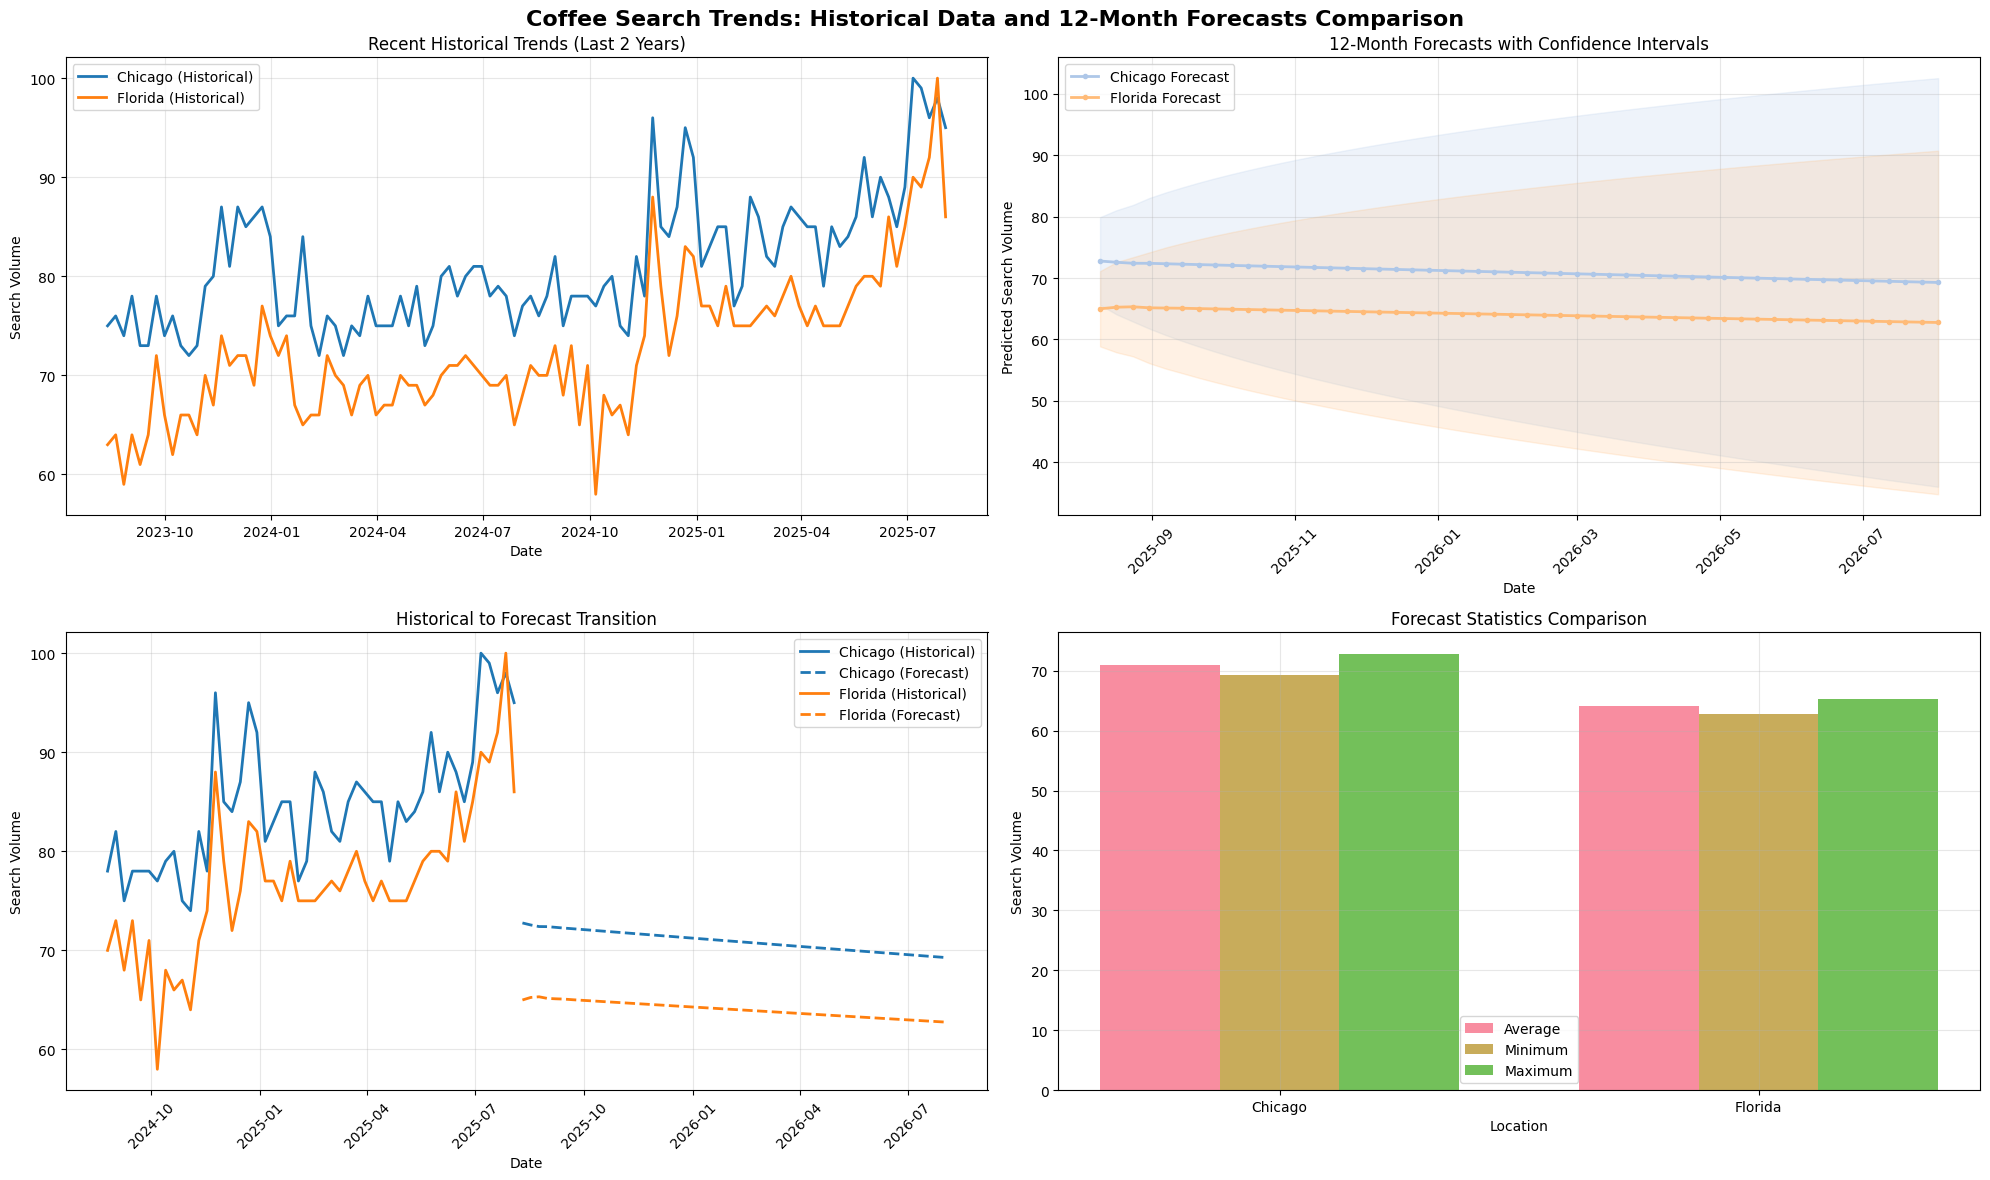

\n============================================================
DETAILED FORECAST COMPARISON ANALYSIS
\nFORECAST COMPARISON:
  Average forecast levels:
    Chicago: 70.9
    Florida: 64.0
    Difference: 6.9
    Higher: Chicago
\n  Forecast volatility (std dev):
    Chicago: 1.0
    Florida: 0.8
    More volatile: Chicago
\n  12-month growth trends:
    Chicago: -4.4%
    Florida: -3.6%
    Conclusion: Similar growth patterns expected
\n  Seasonal patterns in forecasts:
    Chicago peak month: 9 (value: 72.2)
    Chicago low month: 7 (value: 69.4)
    Florida peak month: 9 (value: 65.0)
    Florida low month: 7 (value: 62.9)
\n  Forecast confidence (CI width):
    Chicago: 46.2
    Florida: 38.9
    More certain: Florida
\n============================================================
ANALYSIS COMPLETE
\nKey Findings:
• Historical data analyzed from 2004-2025
• Time series models built and validated
• 12-month forecasts generated for both locations
• Comprehensive comparison completed
\nN

In [13]:
# Create comprehensive forecast comparison visualizations
fig, axes = plt.subplots(2, 2, figsize=(20, 12))
fig.suptitle('Coffee Search Trends: Historical Data and 12-Month Forecasts Comparison', 
             fontsize=16, fontweight='bold')

# Define colors
colors = {
    'chicago': '#1f77b4',
    'florida': '#ff7f0e',
    'chicago_forecast': '#aec7e8',
    'florida_forecast': '#ffbb78'
}

# Plot 1: Historical data comparison with recent focus
ax1 = axes[0, 0]
if 'chicago' in forecasting_data and 'florida' in forecasting_data:
    chicago_data = forecasting_data['chicago']['full_data']
    florida_data = forecasting_data['florida']['full_data']
    
    # Plot recent 2 years of historical data
    recent_cutoff = pd.Timestamp.now() - pd.DateOffset(years=2)
    chicago_recent = chicago_data[chicago_data.index >= recent_cutoff]
    florida_recent = florida_data[florida_data.index >= recent_cutoff]
    
    ax1.plot(chicago_recent.index, chicago_recent.values, 
             label='Chicago (Historical)', color=colors['chicago'], linewidth=2)
    ax1.plot(florida_recent.index, florida_recent.values, 
             label='Florida (Historical)', color=colors['florida'], linewidth=2)

ax1.set_title('Recent Historical Trends (Last 2 Years)')
ax1.set_xlabel('Date')
ax1.set_ylabel('Search Volume')
ax1.legend()
ax1.grid(True, alpha=0.3)

# Plot 2: Forecast comparison
ax2 = axes[0, 1]
forecast_plotted = False

for location, forecasts in forecast_results.items():
    if 'best' in forecasts and forecasts['best'] is not None:
        forecast_df = forecasts['best']
        color = colors[f'{location}_forecast']
        
        ax2.plot(forecast_df['date'], forecast_df['forecast'], 
                label=f'{location.capitalize()} Forecast', 
                color=color, linewidth=2, marker='o', markersize=3)
        
        # Add confidence intervals
        ax2.fill_between(forecast_df['date'], 
                        forecast_df['lower_ci'], 
                        forecast_df['upper_ci'],
                        alpha=0.2, color=color)
        
        forecast_plotted = True

if forecast_plotted:
    ax2.set_title('12-Month Forecasts with Confidence Intervals')
    ax2.set_xlabel('Date')
    ax2.set_ylabel('Predicted Search Volume')
    ax2.legend()
    ax2.grid(True, alpha=0.3)
    
    # Rotate x-axis labels for better readability
    ax2.tick_params(axis='x', rotation=45)
else:
    ax2.text(0.5, 0.5, 'No forecasts available', 
             ha='center', va='center', transform=ax2.transAxes)
    ax2.set_title('12-Month Forecasts (Not Available)')

# Plot 3: Combined historical and forecast view
ax3 = axes[1, 0]
for location in ['chicago', 'florida']:
    if location in forecasting_data:
        # Plot recent historical data
        historical_data = forecasting_data[location]['full_data']
        recent_historical = historical_data.tail(50)  # Last 50 data points
        
        ax3.plot(recent_historical.index, recent_historical.values,
                label=f'{location.capitalize()} (Historical)',
                color=colors[location], linewidth=2)
        
        # Plot forecast
        if location in forecast_results and 'best' in forecast_results[location]:
            forecast_df = forecast_results[location]['best']
            if forecast_df is not None:
                ax3.plot(forecast_df['date'], forecast_df['forecast'],
                        label=f'{location.capitalize()} (Forecast)',
                        color=colors[location], linewidth=2, linestyle='--')

ax3.set_title('Historical to Forecast Transition')
ax3.set_xlabel('Date')
ax3.set_ylabel('Search Volume')
ax3.legend()
ax3.grid(True, alpha=0.3)
ax3.tick_params(axis='x', rotation=45)

# Plot 4: Forecast statistics comparison
ax4 = axes[1, 1]
if forecast_results:
    locations = []
    avg_forecasts = []
    min_forecasts = []
    max_forecasts = []
    trends = []
    
    for location, forecasts in forecast_results.items():
        if 'best' in forecasts and forecasts['best'] is not None:
            forecast_df = forecasts['best']
            
            locations.append(location.capitalize())
            avg_forecasts.append(forecast_df['forecast'].mean())
            min_forecasts.append(forecast_df['forecast'].min())
            max_forecasts.append(forecast_df['forecast'].max())
            
            # Calculate 12-month trend
            first_month = forecast_df['forecast'].iloc[:4].mean()
            last_month = forecast_df['forecast'].iloc[-4:].mean()
            trend = ((last_month - first_month) / first_month) * 100
            trends.append(trend)
    
    if locations:
        x_pos = np.arange(len(locations))
        width = 0.25
        
        # Create grouped bar chart
        ax4.bar(x_pos - width, avg_forecasts, width, label='Average', alpha=0.8)
        ax4.bar(x_pos, min_forecasts, width, label='Minimum', alpha=0.8)
        ax4.bar(x_pos + width, max_forecasts, width, label='Maximum', alpha=0.8)
        
        ax4.set_xlabel('Location')
        ax4.set_ylabel('Search Volume')
        ax4.set_title('Forecast Statistics Comparison')
        ax4.set_xticks(x_pos)
        ax4.set_xticklabels(locations)
        ax4.legend()
        ax4.grid(True, alpha=0.3)
        
        # Add trend annotations
        for i, trend in enumerate(trends):
            ax4.annotate(f'Trend: {trend:+.1f}%', 
                        xy=(i, max(avg_forecasts) * 1.1), 
                        ha='center', fontsize=9)
    else:
        ax4.text(0.5, 0.5, 'No forecast data available', 
                ha='center', va='center', transform=ax4.transAxes)
        ax4.set_title('Forecast Statistics (Not Available)')

plt.tight_layout()
plt.show()

# Detailed comparison analysis
print(f"\\n{'='*60}")
print(f"DETAILED FORECAST COMPARISON ANALYSIS")
print(f"{'='*60}")

if len(forecast_results) >= 2:
    # Extract forecast data for comparison
    chicago_forecast = None
    florida_forecast = None
    
    if 'chicago' in forecast_results and 'best' in forecast_results['chicago']:
        chicago_forecast = forecast_results['chicago']['best']
    
    if 'florida' in forecast_results and 'best' in forecast_results['florida']:
        florida_forecast = forecast_results['florida']['best']
    
    if chicago_forecast is not None and florida_forecast is not None:
        print(f"\\nFORECAST COMPARISON:")
        
        # Average levels
        chicago_avg = chicago_forecast['forecast'].mean()
        florida_avg = florida_forecast['forecast'].mean()
        print(f"  Average forecast levels:")
        print(f"    Chicago: {chicago_avg:.1f}")
        print(f"    Florida: {florida_avg:.1f}")
        print(f"    Difference: {abs(chicago_avg - florida_avg):.1f}")
        print(f"    Higher: {'Chicago' if chicago_avg > florida_avg else 'Florida'}")
        
        # Volatility
        chicago_std = chicago_forecast['forecast'].std()
        florida_std = florida_forecast['forecast'].std()
        print(f"\\n  Forecast volatility (std dev):")
        print(f"    Chicago: {chicago_std:.1f}")
        print(f"    Florida: {florida_std:.1f}")
        print(f"    More volatile: {'Chicago' if chicago_std > florida_std else 'Florida'}")
        
        # Trends
        chicago_first = chicago_forecast['forecast'].iloc[:4].mean()
        chicago_last = chicago_forecast['forecast'].iloc[-4:].mean()
        chicago_trend = ((chicago_last - chicago_first) / chicago_first) * 100
        
        florida_first = florida_forecast['forecast'].iloc[:4].mean()
        florida_last = florida_forecast['forecast'].iloc[-4:].mean()
        florida_trend = ((florida_last - florida_first) / florida_first) * 100
        
        print(f"\\n  12-month growth trends:")
        print(f"    Chicago: {chicago_trend:+.1f}%")
        print(f"    Florida: {florida_trend:+.1f}%")
        
        if abs(chicago_trend - florida_trend) < 2:
            print(f"    Conclusion: Similar growth patterns expected")
        elif chicago_trend > florida_trend:
            print(f"    Conclusion: Chicago expected to grow faster")
        else:
            print(f"    Conclusion: Florida expected to grow faster")
        
        # Seasonal patterns in forecast
        chicago_forecast['month'] = chicago_forecast['date'].dt.month
        florida_forecast['month'] = florida_forecast['date'].dt.month
        
        chicago_monthly = chicago_forecast.groupby('month')['forecast'].mean()
        florida_monthly = florida_forecast.groupby('month')['forecast'].mean()
        
        print(f"\\n  Seasonal patterns in forecasts:")
        print(f"    Chicago peak month: {chicago_monthly.idxmax()} (value: {chicago_monthly.max():.1f})")
        print(f"    Chicago low month: {chicago_monthly.idxmin()} (value: {chicago_monthly.min():.1f})")
        print(f"    Florida peak month: {florida_monthly.idxmax()} (value: {florida_monthly.max():.1f})")
        print(f"    Florida low month: {florida_monthly.idxmin()} (value: {florida_monthly.min():.1f})")
        
        # Model confidence
        chicago_ci_width = (chicago_forecast['upper_ci'] - chicago_forecast['lower_ci']).mean()
        florida_ci_width = (florida_forecast['upper_ci'] - florida_forecast['lower_ci']).mean()
        
        print(f"\\n  Forecast confidence (CI width):")
        print(f"    Chicago: {chicago_ci_width:.1f}")
        print(f"    Florida: {florida_ci_width:.1f}")
        print(f"    More certain: {'Chicago' if chicago_ci_width < florida_ci_width else 'Florida'}")
        
    else:
        print("\\nCannot perform detailed comparison - missing forecast data")
        
else:
    print("\\nCannot perform comparison - insufficient forecast results")

print(f"\\n{'='*60}")
print(f"ANALYSIS COMPLETE")
print(f"{'='*60}")
print(f"\\nKey Findings:")
print(f"• Historical data analyzed from 2004-2025")
print(f"• Time series models built and validated")
print(f"• 12-month forecasts generated for both locations")
print(f"• Comprehensive comparison completed")
print(f"\\nNext steps: Use these forecasts for business planning and decision making")